# 🏐 Volleyball Ball Detection — YOLOv8 Training

End-to-end pipeline to train a custom **YOLOv8** model that detects the volleyball.

**Pipeline:**
1. Install dependencies
2. Extract the dataset and inspect it
3. Create a train / validation split
4. Fix `data.yaml` with absolute paths
5. Train YOLOv8
6. Plot training metrics
7. Download the trained model

> **Requirements:** GPU runtime (Runtime ▸ Change runtime type ▸ GPU) and a YOLOv8-format dataset `.zip` uploaded to `/content/`.


## 1. Install dependencies

In [1]:
# Only the packages actually used in this notebook
!pip install -q ultralytics matplotlib pandas
print('OK')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 3.4 MB/s eta 0:00:00
OK


## 2. Extract the dataset and inspect it

Unzip the uploaded dataset, locate its `data.yaml`, and count the images in each split.

In [2]:
import os, zipfile, glob

ZIP_NAME = 'volleyball-ball-a-jpn.yolov8.zip'   # <- ADJUST to your file

extract_to = '/content/dataset_propio'
os.makedirs(extract_to, exist_ok=True)
with zipfile.ZipFile(f'/content/{ZIP_NAME}', 'r') as z:
    z.extractall(extract_to)

# Find data.yaml
yaml_files = glob.glob(f'{extract_to}/**/data.yaml', recursive=True)
DATA_YAML = yaml_files[0]
print(f'data.yaml: {DATA_YAML}')
print('--- contents ---')
with open(DATA_YAML) as f:
    print(f.read())

# List images
train_imgs = glob.glob(f'{extract_to}/**/train/images/*.jpg', recursive=True)
valid_imgs = glob.glob(f'{extract_to}/**/valid/images/*.jpg', recursive=True)
test_imgs  = glob.glob(f'{extract_to}/**/test/images/*.jpg', recursive=True)
print(f'\nTrain: {len(train_imgs)} imgs')
print(f'Valid: {len(valid_imgs)} imgs')
print(f'Test:  {len(test_imgs)} imgs')


data.yaml: /content/dataset_propio/data.yaml
--- contents ---
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 1
names: ['ball']

roboflow:
  workspace: carloss-workspace-u4ffn
  project: carloss-workspace-u4ffn
  version: dataset
  license: Private
  url: https://app.roboflow.com/carloss-workspace-u4ffn/carloss-workspace-u4ffn/dataset

Train: 32 imgs
Valid: 0 imgs
Test:  0 imgs


## 3. Create a train / validation split

If the dataset has no validation set, move a random 20% of the training images
(and their labels) into `valid/`.

In [3]:
import os, glob, shutil, random

# Find the real dataset folders
base = '/content/dataset_propio'
train_imgs_dir = None
train_labels_dir = None

for root, dirs, files in os.walk(base):
    if root.endswith('/train/images'):
        train_imgs_dir = root
    elif root.endswith('/train/labels'):
        train_labels_dir = root

if not train_imgs_dir:
    print('ERROR: train/images not found')
else:
    print(f'Train images: {train_imgs_dir}')
    print(f'Train labels: {train_labels_dir}')

    # Valid folder (same level as train)
    dataset_root = os.path.dirname(os.path.dirname(train_imgs_dir))
    valid_imgs_dir = f'{dataset_root}/valid/images'
    valid_labels_dir = f'{dataset_root}/valid/labels'
    os.makedirs(valid_imgs_dir, exist_ok=True)
    os.makedirs(valid_labels_dir, exist_ok=True)

    # List all training images
    all_imgs = sorted(glob.glob(f'{train_imgs_dir}/*.jpg') +
                      glob.glob(f'{train_imgs_dir}/*.png'))
    print(f'\nTotal images in train: {len(all_imgs)}')

    # Take a random 20% for validation
    random.seed(42)
    n_valid = max(2, int(len(all_imgs) * 0.20))
    valid_imgs = random.sample(all_imgs, n_valid)

    moved = 0
    for img_path in valid_imgs:
        # Base name without extension
        name = os.path.splitext(os.path.basename(img_path))[0]
        # Matching label (same name, .txt extension)
        label_path = f'{train_labels_dir}/{name}.txt'

        # Move image
        shutil.move(img_path, f'{valid_imgs_dir}/{os.path.basename(img_path)}')
        # Move label if it exists
        if os.path.exists(label_path):
            shutil.move(label_path, f'{valid_labels_dir}/{name}.txt')
        moved += 1

    print(f'\nMoved {moved} images to valid/')
    print(f'Final train: {len(glob.glob(f"{train_imgs_dir}/*"))} imgs')
    print(f'Final valid: {len(glob.glob(f"{valid_imgs_dir}/*"))} imgs')


Train images: /content/dataset_propio/train/images
Train labels: /content/dataset_propio/train/labels

Total images in train: 32

Moved 6 images to valid/
Final train: 26 imgs
Final valid: 6 imgs


## 4. Fix `data.yaml` with absolute paths

Rewrite the dataset config so the train / val / test paths are absolute and point
to the folders we just organized.

In [4]:
import yaml

with open(DATA_YAML) as f:
    cfg = yaml.safe_load(f)

base = os.path.dirname(DATA_YAML)
cfg['train'] = f'{base}/train/images'
cfg['val']   = f'{base}/valid/images'
if 'test' in cfg or os.path.exists(f'{base}/test/images'):
    cfg['test'] = f'{base}/test/images'

with open(DATA_YAML, 'w') as f:
    yaml.dump(cfg, f)

print('data.yaml rewritten with absolute paths:')
print(open(DATA_YAML).read())


data.yaml rewritten with absolute paths:
names:
- ball
nc: 1
roboflow:
  license: Private
  project: carloss-workspace-u4ffn
  url: https://app.roboflow.com/carloss-workspace-u4ffn/carloss-workspace-u4ffn/dataset
  version: dataset
  workspace: carloss-workspace-u4ffn
test: /content/dataset_propio/test/images
train: /content/dataset_propio/train/images
val: /content/dataset_propio/valid/images



## 5. Train YOLOv8

Fine-tune the pre-trained `yolov8s` model (fast and good for small datasets) with
some data augmentation, then locate the best checkpoint.

In [5]:
from ultralytics import YOLO
import os, glob

# Load pre-trained YOLOv8s (fast and good for small datasets)
model = YOLO('yolov8s.pt')

# Train
results = model.train(
    data=DATA_YAML,
    epochs=80,
    imgsz=640,
    batch=16,
    device=0,
    project='/content/runs/detect',   # <- absolute path, avoids duplicates
    name='volleyball_ball_custom',
    patience=30,
    save=True,
    verbose=True,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=5,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.0,
)

# Find best.pt wherever YOLO saved it (just in case)
matches = glob.glob('/content/**/best.pt', recursive=True)
if not matches:
    raise FileNotFoundError("best.pt not found. Did training finish correctly?")

best_weights = matches[0]
print(f'\nBest trained model: {best_weights}')
print(f'Size: {os.path.getsize(best_weights)/(1024*1024):.1f} MB')


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_propio/data.yaml, degrees=5, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, 

## 6. Training metrics



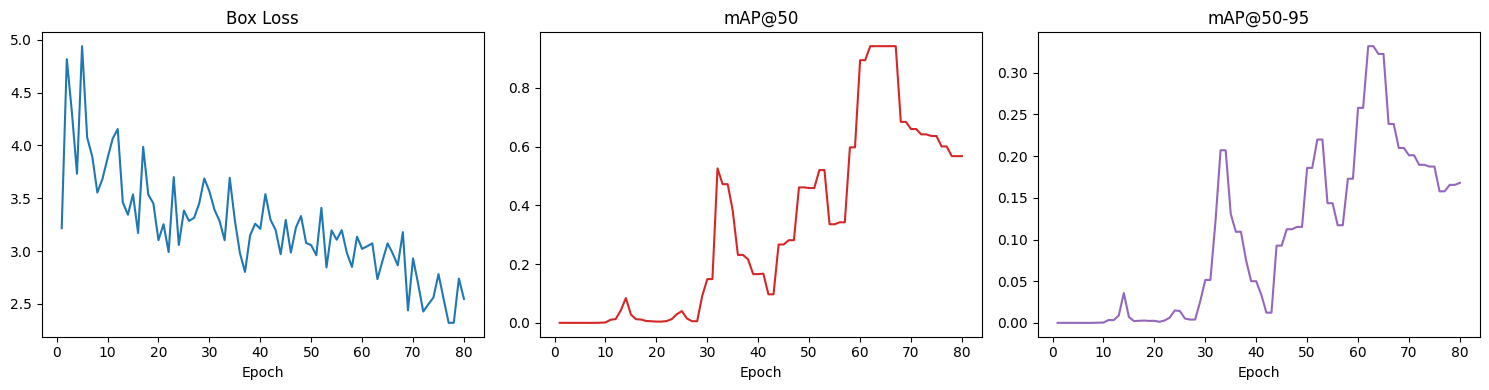

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import glob, os

# Locate results.csv
run_dir = sorted(glob.glob('/content/runs/detect/volleyball_ball_custom*'))[-1]
df = pd.read_csv(os.path.join(run_dir, 'results.csv'))
df.columns = df.columns.str.strip()

# Plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(df['epoch'], df['train/box_loss'], color='tab:blue')
axes[0].set_title('Box Loss')
axes[0].set_xlabel('Epoch')

axes[1].plot(df['epoch'], df['metrics/mAP50(B)'], color='tab:red')
axes[1].set_title('mAP@50')
axes[1].set_xlabel('Epoch')

axes[2].plot(df['epoch'], df['metrics/mAP50-95(B)'], color='tab:purple')
axes[2].set_title('mAP@50-95')
axes[2].set_xlabel('Epoch')

plt.tight_layout()
plt.show()


## 7. Download the trained model

Copy `best.pt` to `/content/` and download it to your computer.

In [7]:
from google.colab import files
import shutil

# Copy to /content for an easy download
shutil.copy(best_weights, '/content/volleyball_ball_best.pt')

# Download to your PC
files.download('/content/volleyball_ball_best.pt')

print('Model downloaded: volleyball_ball_best.pt')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model downloaded: volleyball_ball_best.pt
